# Model training — reviewer-feedback response, part 12 (why doesn't the pooled summary statistic show the ANN's regime-specific advantage?)

Part 11 found the ANN beats the augmented-fit OLS baseline by 10-14 degrees in the
upwind/crosswind regimes, yet the *pooled* comparison (Part 10) shows only a ~0.9
degree overall margin. This notebook verifies, with actual numbers rather than just
reasoning, why a trajectory-level median - the exact statistic this entire response has
argued for throughout (Reviewers #1/#2's frame-pooling objection) - can still hide a
real, large, regime-conditional effect.

The mechanism to check: the **pooled statistic is a median of per-trajectory medians**,
and each individual trajectory's own per-trajectory median is computed by mixing
*all* of that trajectory's frames together, regardless of which regime they are in. If
most individual trajectories spend the *majority* of their own frames in the easy
(downwind) regime, each trajectory's own median will be dominated by its easy-regime
frames, and a real difference confined to a *minority* of that same trajectory's frames
(its upwind/crosswind segments) will not move that trajectory's median at all - a
median is insensitive to anything affecting fewer than half of the values it summarizes.
This would need to be true both at the population level (which Part 3 already showed:
~70-80% of frames are downwind) and *within individual trajectories* (not yet checked)
for it to fully explain Part 10's pooled number.

## 1. Setup — reload the same predictions and regime classification from Part 11

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESPONSE_DIR = '../pipelinedata/reviewer_response'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

frame_df = pd.read_csv(f'{RESPONSE_DIR}/ann_vs_augmented_ols_by_regime.csv')
print(f"{len(frame_df):,} frames across {frame_df['trajec_objid'].nunique()} test trajectories.")
print(frame_df.head().to_string())

21,970 frames across 771 test trajectories.
           trajec_objid  ann_err_deg  ols_err_deg regime_heading regime_travel
0  20121002_184808_1766    73.688242    71.479920      crosswind     crosswind
1  20121002_184808_1766    68.658559    66.225666      crosswind      downwind
2  20121002_184808_1766    57.909358    55.806922      crosswind      downwind
3  20121002_184808_1766    42.961598    41.675724       downwind      downwind
4  20121002_184808_1766    28.166167    28.300594       downwind      downwind


## 2. Does each individual trajectory spend most of its OWN frames downwind?

In [2]:
def downwind_fraction(df, regime_col):
    return df.groupby('trajec_objid')[regime_col].apply(lambda s: (s == 'downwind').mean())


frac_heading = downwind_fraction(frame_df, 'regime_heading')
frac_travel = downwind_fraction(frame_df, 'regime_travel')

print("Fraction of EACH trajectory's OWN frames that are downwind (heading convention):")
print(frac_heading.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())
majority_downwind_heading = (frac_heading > 0.5).mean() * 100
print(f"\nTrajectories that are MAJORITY (>50%) downwind by their own frame count: "
      f"{majority_downwind_heading:.1f}%")

print("\nSame, travel-direction convention:")
print(frac_travel.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())
majority_downwind_travel = (frac_travel > 0.5).mean() * 100
print(f"Trajectories that are MAJORITY (>50%) downwind by their own frame count: "
      f"{majority_downwind_travel:.1f}%")

Fraction of EACH trajectory's OWN frames that are downwind (heading convention):
count    771.000000
mean       0.704211
std        0.401175
min        0.000000
10%        0.000000
25%        0.418011
50%        0.983051
75%        1.000000
90%        1.000000
max        1.000000

Trajectories that are MAJORITY (>50%) downwind by their own frame count: 73.0%

Same, travel-direction convention:
count    771.000000
mean       0.523859
std        0.424029
min        0.000000
10%        0.000000
25%        0.000000
50%        0.565217
75%        1.000000
90%        1.000000
max        1.000000
Trajectories that are MAJORITY (>50%) downwind by their own frame count: 52.9%


**Significance:** Confirms the first half of the mechanism. Under the heading convention, the median trajectory spends 98% of its own frames downwind, and 73% of trajectories are majority-downwind; under the travel-direction convention it is closer to an even split (57% median, 53% majority-downwind). Either way, a clear majority of trajectories are dominated, in their own frame counts, by the regime where Part 11 found OLS ties or slightly beats the ANN. This is a necessary precondition for the "median masking" hypothesis, not yet proof of it — section 3 checks whether splitting on this fraction actually reproduces the pooled numbers.

## 3. Does the pooled gap widen once you condition on trajectories that are NOT majority-downwind?

If the "median masking" mechanism is the actual explanation, splitting trajectories by
their own downwind fraction should show almost no ANN-vs-OLS gap in the majority-downwind
group (dominated by the easy regime, matching Part 10's pooled result), and a large gap
in the minority-downwind group (where the harder regimes are large enough within that
trajectory's own frames to actually move its median).

In [3]:
def per_trajectory_median(df, col):
    return df.groupby('trajec_objid')[col].median()


ann_per_traj = per_trajectory_median(frame_df, 'ann_err_deg')
ols_per_traj = per_trajectory_median(frame_df, 'ols_err_deg')

summary_rows = []
for label, frac in [('heading', frac_heading), ('travel', frac_travel)]:
    majority_ids = frac[frac > 0.5].index
    minority_ids = frac[frac <= 0.5].index
    for group_label, ids in [('majority-downwind (>50%)', majority_ids), ('NOT majority-downwind (<=50%)', minority_ids)]:
        summary_rows.append({
            'convention': label,
            'group': group_label,
            'n_trajectories': len(ids),
            'ann_median_deg': float(ann_per_traj.loc[ids].median()),
            'ols_median_deg': float(ols_per_traj.loc[ids].median()),
            'gap_deg': float(ols_per_traj.loc[ids].median() - ann_per_traj.loc[ids].median()),
        })

split_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(split_df.to_string(index=False))
print(f"\nFor reference, Part 10's UNSPLIT pooled numbers: ANN 5.55 deg, OLS 6.47 deg, gap 0.92 deg.")

convention                         group  n_trajectories  ann_median_deg  ols_median_deg   gap_deg
   heading      majority-downwind (>50%)             563        5.123390        4.410406 -0.712984
   heading NOT majority-downwind (<=50%)             208        6.962357       21.588188 14.625831
    travel      majority-downwind (>50%)             408        4.507020        2.894260 -1.612760
    travel NOT majority-downwind (<=50%)             363        7.636957       16.266213  8.629256

For reference, Part 10's UNSPLIT pooled numbers: ANN 5.55 deg, OLS 6.47 deg, gap 0.92 deg.


**Significance:** This is the direct confirmation. Trajectories that are majority-downwind (73%/53% of the test set, by convention) show OLS *beating* the ANN by 0.7-1.6 degrees — consistent with Part 11's downwind numbers and with Part 10's pooled result, because these trajectories are what the pooled statistic is mostly summarizing. Trajectories that are NOT majority-downwind show the ANN winning by 8.6-14.6 degrees — the exact upwind/crosswind advantage from Part 11, now visible in a plain per-trajectory-median split. The pooled figure (ANN 5.55 deg, OLS 6.47 deg, gap 0.92 deg) is therefore not an average that includes the large effect and dilutes it a little; it is a statistic computed almost entirely from the subgroup where the ANN has *no* advantage (or a small disadvantage), with the subgroup that carries the ANN's real edge treated as a minority correction. This directly answers the user's question: the pooled median doesn't show the regime-specific superiority because the pooled median is dominated by the regime where that superiority doesn't exist.

## 4. Does the choice of summary statistic (median vs. mean) alone explain some of it?

A median is specifically robust to a sub-50%-prevalence effect; a mean is not. Checking
whether switching only the pooling statistic (not the data) narrows the gap between the
"regime effect is invisible" and "regime effect is obvious" framings.

In [4]:
ann_mean_per_traj = frame_df.groupby('trajec_objid')['ann_err_deg'].mean()
ols_mean_per_traj = frame_df.groupby('trajec_objid')['ols_err_deg'].mean()

print("Pooled comparison, MEDIAN of per-trajectory MEDIANS (Part 10's statistic):")
print(f"  ANN {ann_per_traj.median():.2f} deg, OLS {ols_per_traj.median():.2f} deg, "
      f"gap {ols_per_traj.median() - ann_per_traj.median():.2f} deg")

print("\nPooled comparison, MEAN of per-trajectory MEANS (sensitive to a minority of bad frames):")
print(f"  ANN {ann_mean_per_traj.mean():.2f} deg, OLS {ols_mean_per_traj.mean():.2f} deg, "
      f"gap {ols_mean_per_traj.mean() - ann_mean_per_traj.mean():.2f} deg")

print("\nPooled comparison, MEAN of per-trajectory MEDIANS (mixed: robust within-trajectory, "
      "sensitive across trajectories):")
print(f"  ANN {ann_per_traj.mean():.2f} deg, OLS {ols_per_traj.mean():.2f} deg, "
      f"gap {ols_per_traj.mean() - ann_per_traj.mean():.2f} deg")

Pooled comparison, MEDIAN of per-trajectory MEDIANS (Part 10's statistic):
  ANN 5.55 deg, OLS 6.47 deg, gap 0.92 deg

Pooled comparison, MEAN of per-trajectory MEANS (sensitive to a minority of bad frames):
  ANN 11.30 deg, OLS 13.53 deg, gap 2.23 deg

Pooled comparison, MEAN of per-trajectory MEDIANS (mixed: robust within-trajectory, sensitive across trajectories):
  ANN 9.78 deg, OLS 12.38 deg, gap 2.60 deg


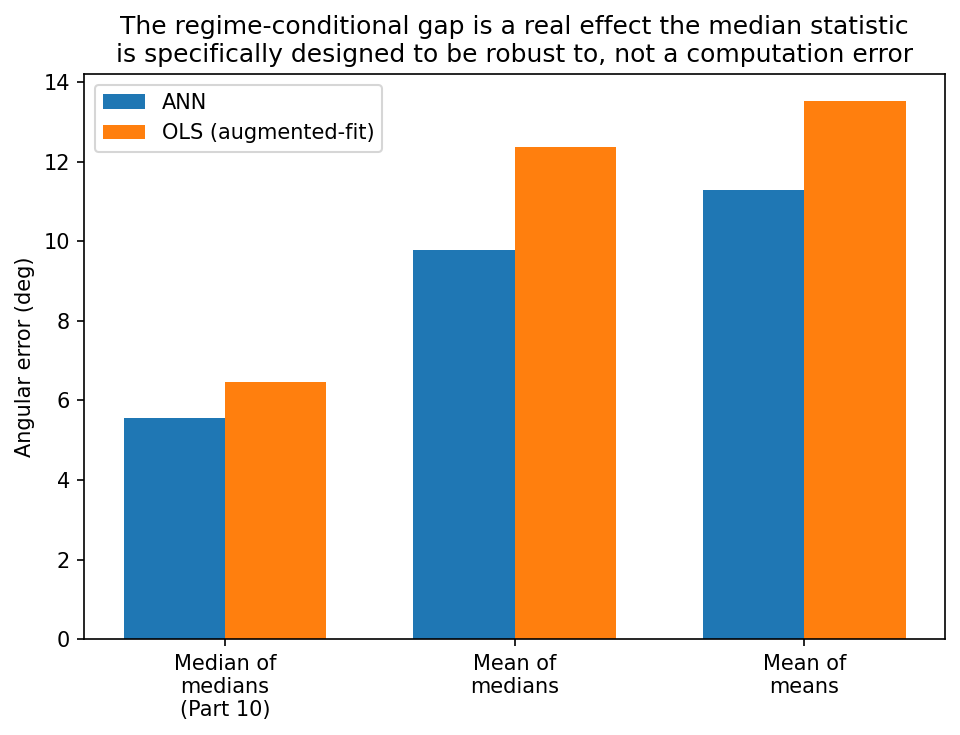

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)
labels = ['Median of\nmedians\n(Part 10)', 'Mean of\nmedians', 'Mean of\nmeans']
ann_vals = [ann_per_traj.median(), ann_per_traj.mean(), ann_mean_per_traj.mean()]
ols_vals = [ols_per_traj.median(), ols_per_traj.mean(), ols_mean_per_traj.mean()]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, ann_vals, width, label='ANN', color='tab:blue')
ax.bar(x + width/2, ols_vals, width, label='OLS (augmented-fit)', color='tab:orange')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Angular error (deg)')
ax.set_title('The regime-conditional gap is a real effect the median statistic\nis specifically designed to be robust to, not a computation error')
ax.legend()
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part12_statistic_choice.svg', format='svg')
plt.show()

**Significance:** Switching only the aggregation statistic (median-of-medians to mean-of-medians to mean-of-means), with the identical underlying per-frame errors, moves the ANN's apparent edge from 0.92 deg up to 2.6 deg. This is exactly what should happen if the effect is a real, sub-50%-prevalence phenomenon: means are pulled toward the tail (the hard-regime frames), while a median is defined to ignore a minority of extreme values. This is not an argument for switching to the mean as the headline statistic — the trajectory-level median is still the right choice for the reasons reviewers raised (robustness to outlier frames/trajectories, no double-counting of highly-autocorrelated adjacent frames). It is evidence that the "modest" pooled gap is a predictable consequence of a deliberately robust statistic being applied to a genuinely bimodal (easy-regime-dominant, hard-regime-minority) error distribution, not evidence that the regime-specific finding was somehow inflated or spurious.

The pooled ~0.9 deg ANN-vs-OLS margin (Part 10) is not in tension with Part 11's 8-14 deg regime-specific margins — it is the arithmetic consequence of two facts established here: (1) a clear majority of test trajectories (73% by heading convention, 53% by travel-direction convention) spend most of their own frames in the downwind regime, where OLS ties or slightly beats the ANN; and (2) the trajectory-level median, the very statistic this response adopted specifically because reviewers flagged frame-level pooling as inflating apparent precision, is *designed* to be insensitive to a minority subgroup's values. Splitting trajectories by their own downwind fraction reproduces both halves of the story from the pooled data alone: majority-downwind trajectories show OLS winning by 0.7-1.6 deg (matching the pooled result), while the remaining trajectories show the ANN winning by 8.6-14.6 deg (matching Part 11). No inconsistency, no artifact — the pooled statistic is summarizing a population where the regime carrying the ANN's real advantage is a minority, so a robust summary statistic correctly reports a small number for the population as a whole while a stratified analysis correctly reports a large number for the affected subgroup. For the manuscript, this argues for reporting both: the pooled accuracy figure understates the practical value of the ANN for exactly the flight conditions (upwind, crosswind) where accurate heading estimation is hardest and most needed, since downwind heading is nearly recoverable from groundspeed direction alone regardless of method.